# STEP 1. OSM 보행 네트워크 재구축 (S / C 두 변형)

**목적**: 공원 간 configurational 관계를 계산할 보행 네트워크를 다시 만든다.

기존 `nyc_walk.graphml`(01번 노트북)의 문제:
1. `retain_all=False` → 최대 연결요소만 남아 **Staten Island 전체 누락**
2. `footway`/`crossing`/`sidewalk` 태그 미저장 → 보도·횡단보도 구분 불가
3. OSMnx 기본 `walk` 필터가 `sidewalk=separate` 도로(보도를 별도 way로 그린 도로)를 **제외** → 보도가 따로 그려진 구간은 중심선이 없고, 그렇지 않은 구간은 중심선만 있는 **혼합 네트워크**

**해결**: walk 필터에서 `sidewalk=separate` 조건 4개만 제거한 custom filter로 NYC + 3.2 km 버퍼를 한 번에 다운로드(`retain_all=True`, 태그 추가).

**두 변형**
- **C (주 분석)**: 보도(`footway=sidewalk`)·횡단보도(`crossing`)·교통섬(`traffic_island`)을 제거한 **가로 중심선 + 보행전용 경로**. Space Syntax의 segment map에 해당. 보도 제거로 끊긴 보행전용 경로 끝점은 25 m 이내 가로 중심선에 connector로 재연결.
- **S (민감도)**: 보도를 포함한 전체 보행망. 길 건너편 공원이 보도→횡단보도→보도로 약 180°가 되는 인공물이 있어 민감도 분석용.

**출력**: `Data/derived/network/segments_{C,S}.parquet`, `boundaries.gpkg`

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# N2 configurational corridor
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=Brooklyn  boroughs=['B']  AREA_DIR=Data/derived/Brooklyn


In [2]:
import networkx as nx
import osmnx as ox
import shapely
from shapely.geometry import LineString, Point
from shapely.ops import substring
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt

print("osmnx", ox.__version__, "| shapely", shapely.__version__)

ox.settings.use_cache = True
ox.settings.cache_folder = str(ROOT / "cache")
ox.settings.log_console = False
ox.settings.requests_timeout = 900
ox.settings.max_query_area_size = 400 * 1000 * 1000   # 400 km² 단위로 나눠 요청 (타임아웃 방지)
EXTRA_TAGS = ["footway", "crossing", "sidewalk", "sidewalk:both", "sidewalk:left", "sidewalk:right", "foot", "access"]
ox.settings.useful_tags_way = list(dict.fromkeys(list(ox.settings.useful_tags_way) + EXTRA_TAGS))

# OSMnx 2.0.2 walk 필터에서 sidewalk=separate 제외 조건 4개만 뺀 것
CUSTOM_WALK = (
    f'["highway"]["area"!~"yes"]{ox.settings.default_access}'
    '["highway"!~"abandoned|bus_guideway|construction|cycleway|motor|no|planned|platform|'
    'proposed|raceway|razed"]'
    '["foot"!~"no"]["service"!~"private"]'
)
print(CUSTOM_WALK)

osmnx 2.0.2 | shapely 2.1.2
["highway"]["area"!~"yes"]["access"!~"private"]["highway"!~"abandoned|bus_guideway|construction|cycleway|motor|no|planned|platform|proposed|raceway|razed"]["foot"!~"no"]["service"!~"private"]


## 1-1. 경계 (NYC, 5개 보로) 와 다운로드 영역
다운로드 영역 = NYC 경계를 `R_MAX`(3.2 km)만큼 버퍼. 경계 밖(웨스트체스터, 나소, NJ 일부) 세그먼트는 이후 단계에서 dead 노드로만 쓰여 경계 효과를 줄인다.

In [3]:
BND_PATH = NET_DIR / "boundaries.gpkg"
if BND_PATH.exists():
    nyc = gpd.read_file(BND_PATH, layer="nyc")
    boroughs = gpd.read_file(BND_PATH, layer="boroughs")
else:
    nyc = ox.geocode_to_gdf("New York City, New York, USA")[["geometry"]].to_crs(CRS)
    queries = {"M": "Manhattan, New York, USA", "X": "The Bronx, New York, USA", "B": "Brooklyn, New York, USA",
               "Q": "Queens, New York, USA", "R": "Staten Island, New York, USA"}
    rows = []
    for code, q in queries.items():
        g = ox.geocode_to_gdf(q).to_crs(CRS)
        rows.append({"borough": code, "name": BOROUGHS[code], "geometry": g.geometry.iloc[0]})
    boroughs = gpd.GeoDataFrame(rows, crs=CRS)
    nyc.to_file(BND_PATH, layer="nyc")
    boroughs.to_file(BND_PATH, layer="boroughs")

boroughs["area_km2"] = boroughs.area / 1e6
print(boroughs[["borough", "name", "area_km2"]])
query_poly = gpd.GeoSeries([nyc.union_all().buffer(R_MAX)], crs=CRS).to_crs(4326).iloc[0]
print(f"query area ≈ {gpd.GeoSeries([query_poly], crs=4326).to_crs(CRS).area.iloc[0] / 1e6:,.0f} km²")

  borough           name    area_km2
0       M      Manhattan   86.748088
1       X          Bronx  148.868728
2       B       Brooklyn  252.128282
3       Q         Queens  465.065448
4       R  Staten Island  265.404884
query area ≈ 1,800 km²


## 1-2. 다운로드 → 단순화 → 무방향 edge 테이블
- `simplify=False`로 받은 뒤 `simplify_graph(edge_attrs_differ=["highway","footway"])`: 보도와 횡단보도가 한 edge로 합쳐지지 않도록 태그가 바뀌는 노드는 유지.
- `to_undirected`: 보행은 양방향이므로 OSMnx의 양방향 중복 edge 제거.

In [4]:
RAW_EDGES = NET_DIR / "osm_edges_raw.parquet"
if RAW_EDGES.exists():
    edges = gpd.read_parquet(RAW_EDGES)
else:
    t0 = time.time()
    G = ox.graph_from_polygon(query_poly, custom_filter=CUSTOM_WALK, simplify=False,
                              retain_all=True, truncate_by_edge=True)
    print(f"raw graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges ({time.time() - t0:.0f}s)")
    G = ox.simplify_graph(G, edge_attrs_differ=["highway", "footway"])
    G = ox.convert.to_undirected(G)
    print(f"simplified undirected: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
    edges = ox.graph_to_gdfs(G, nodes=False).reset_index()
    del G

    def _flat(x):
        """list 값은 ';'로 합치고, 나머지는 문자열로 통일 (parquet 저장용)."""
        if isinstance(x, (list, tuple, set)):
            return ";".join(sorted(map(str, x)))
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return None
        return str(x)

    keep = ["u", "v", "key", "osmid", "highway", "footway", "crossing", "sidewalk", "sidewalk:both",
            "sidewalk:left", "sidewalk:right", "foot", "access", "service", "name", "bridge", "tunnel", "geometry"]
    edges = edges[[c for c in keep if c in edges.columns]].copy()
    for c in edges.columns:
        if c not in ("geometry", "u", "v", "key"):
            edges[c] = edges[c].map(_flat).astype(object)
    edges = edges.to_crs(CRS)
    edges.to_parquet(RAW_EDGES)
print(f"{len(edges):,} undirected edges")
edges["highway"].value_counts().head(15)

raw graph: 1,377,904 nodes, 3,164,898 edges (131s)


simplified undirected: 696,777 nodes, 1,020,751 edges


1,020,751 undirected edges


highway
footway           638838
residential       173671
service           104983
secondary          31178
tertiary           29030
primary            20384
steps               6170
unclassified        4890
path                4298
pedestrian          2344
trunk               1496
track                801
primary_link         631
secondary_link       611
tertiary_link        412
Name: count, dtype: int64

## 1-3. 세그먼트 분류
`kind`: `sidewalk` / `crossing` / `traffic_island` (보도류), `street`(차도 중심선), `service`, `path`(보행전용).

`sep_sidewalk`: 중심선에 `sidewalk=separate` 태그 → 보도가 따로 그려진 구간 (**regime 공변량**).

In [5]:
PATH_HWY = {"footway", "path", "pedestrian", "steps", "track", "bridleway", "corridor", "elevator", "escalator"}


def classify(row):
    fw = row.get("footway")
    if isinstance(fw, str) and fw in SIDEWALK_FOOTWAYS:
        return fw
    hw = str(row["highway"]).split(";")[0]
    if hw in PATH_HWY:
        return "path"
    if hw == "service":
        return "service"
    return "street"


edges["kind"] = edges.apply(classify, axis=1)
sep_cols = [c for c in ["sidewalk", "sidewalk:both", "sidewalk:left", "sidewalk:right"] if c in edges.columns]
edges["sep_sidewalk"] = edges[sep_cols].apply(
    lambda r: any(isinstance(x, str) and "separate" in x for x in r), axis=1)
edges["seg_id"] = edges["u"].astype(str) + "_" + edges["v"].astype(str) + "_" + edges["key"].astype(str)
edges = edges.set_index("seg_id", drop=False)
print(edges["kind"].value_counts())
print("sep_sidewalk streets:", int((edges.sep_sidewalk & (edges.kind == "street")).sum()))

kind
sidewalk          325730
street            262925
crossing          229801
service           104980
path               92594
traffic_island      4721
Name: count, dtype: int64
sep_sidewalk streets: 111918


## 1-4. 기하 정리 함수
- **self-loop 분할**: 시작점 = 끝점인 세그먼트는 cityseer dual 그래프에서 진입 후 빠져나올 수 없으므로 절반으로 분할.
- **C 변형 connector**: 보도·횡단보도 제거로 끝점이 된(degree 1) 보행전용 경로 끝을 25 m 이내 가장 가까운 가로 중심선(street/service)에 연결. 중심선은 투영점에서 분할(2 m 이내 투영점은 하나로 병합, 끝점 1 m 이내면 끝점에 스냅).
- 연결성은 cityseer와 동일하게 **끝점 좌표(0.1 m 반올림)** 로 판단.

In [6]:
def ep_keys(geoms):
    """Endpoint keys rounded to 0.1 m, as cityseer does."""
    c0 = shapely.get_point(geoms, 0)
    c1 = shapely.get_point(geoms, -1)
    k0 = list(zip(np.round(shapely.get_x(c0), 1), np.round(shapely.get_y(c0), 1)))
    k1 = list(zip(np.round(shapely.get_x(c1), 1), np.round(shapely.get_y(c1), 1)))
    return k0, k1


def split_self_loops(gdf):
    geoms = gdf.geometry.values
    k0, k1 = ep_keys(geoms)
    loop = np.array([a == b for a, b in zip(k0, k1)])
    if not loop.any():
        return gdf
    rows = []
    for sid, row in gdf[loop].iterrows():
        g = row.geometry
        for i, (a, b) in enumerate([(0, g.length / 2), (g.length / 2, g.length)]):
            r = row.copy()
            r["geometry"] = substring(g, a, b)
            r["seg_id"] = f"{sid}~{i}"
            rows.append(r)
    out = pd.concat([gdf[~loop], gpd.GeoDataFrame(rows, crs=gdf.crs)])
    print(f"  split {int(loop.sum())} self-loops")
    return out.set_index("seg_id", drop=False)


def node_degrees(gdf):
    k0, k1 = ep_keys(gdf.geometry.values)
    return pd.Series(k0 + k1).value_counts(), k0, k1


def split_line_at(line, dists):
    cuts = [0.0] + sorted(dists) + [line.length]
    return [substring(line, a, b) for a, b in zip(cuts[:-1], cuts[1:]) if b - a > 1e-6]


def reconnect_orphans(C, S, max_dist=25.0, merge_tol=2.0, snap_tol=1.0):
    """Connect path endpoints orphaned by sidewalk removal to the nearest street centreline."""
    deg_S, _, _ = node_degrees(S)
    deg_C, k0, k1 = node_degrees(C)
    is_path = (C["kind"] == "path").values
    cand = {}
    for i, (a, b) in enumerate(zip(k0, k1)):
        if not is_path[i]:
            continue
        for k in (a, b):
            if deg_C.get(k, 0) == 1 and deg_S.get(k, 0) > 1:
                cand[k] = i
    if not cand:
        return C
    keys = list(cand)
    pts = shapely.points(np.array(keys))
    street_mask = C["kind"].isin(["street", "service"]).values
    street_idx = np.flatnonzero(street_mask)
    street_geoms = C.geometry.values[street_idx]
    tree = shapely.STRtree(street_geoms)
    p_idx, s_local = tree.query(pts, predicate="dwithin", distance=max_dist)
    d = shapely.distance(pts[p_idx], street_geoms[s_local])
    best = pd.DataFrame({"p": p_idx, "s": s_local, "d": d}).sort_values("d").drop_duplicates("p")
    print(f"  orphan path endpoints: {len(keys):,}  connectable within {max_dist} m: {len(best):,}")

    # 투영점 계산 → 대상 선별로 병합
    targets = {}
    connectors = []
    for p, s in zip(best.p.values, best.s.values):
        line = street_geoms[s]
        dist = line.project(pts[p])
        if dist < snap_tol:
            end = shapely.get_point(line, 0)
        elif line.length - dist < snap_tol:
            end = shapely.get_point(line, -1)
        else:
            lst = targets.setdefault(s, [])
            near = [x for x in lst if abs(x - dist) <= merge_tol]
            if near:
                dist = near[0]
            else:
                lst.append(dist)
            end = line.interpolate(dist)
        start = pts[p]
        if start.distance(end) < 0.05:
            continue
        connectors.append(LineString([start.coords[0], end.coords[0]]))

    # 중심선 분할
    new_rows = []
    drop_ids = []
    for s, dists in targets.items():
        gi = street_idx[s]
        row = C.iloc[gi]
        drop_ids.append(row["seg_id"])
        for j, piece in enumerate(split_line_at(street_geoms[s], dists)):
            r = row.copy()
            r["geometry"] = piece
            r["seg_id"] = f"{row['seg_id']}#{j}"
            new_rows.append(r)
    conn = gpd.GeoDataFrame({
        "seg_id": [f"conn_{i}" for i in range(len(connectors))],
        "kind": "connector", "highway": "connector", "sep_sidewalk": False,
    }, geometry=connectors, crs=C.crs)
    out = pd.concat([C.drop(index=drop_ids), gpd.GeoDataFrame(new_rows, crs=C.crs), conn])
    print(f"  added {len(conn):,} connectors, split {len(targets):,} centrelines")
    return out.set_index("seg_id", drop=False)


def add_components(gdf):
    """Connected components on endpoint keys; comp_size = number of segments in the component."""
    k0, k1 = ep_keys(gdf.geometry.values)
    codes, uniques = pd.factorize(pd.Series(k0 + k1))
    n = len(gdf)
    a, b = codes[:n], codes[n:]
    m = coo_matrix((np.ones(n), (a, b)), shape=(len(uniques), len(uniques)))
    _, lab = connected_components(m, directed=False)
    comp = lab[a]
    gdf = gdf.copy()
    gdf["comp_id"] = comp
    gdf["comp_size"] = pd.Series(comp).map(pd.Series(comp).value_counts()).values
    return gdf

## 1-5. S / C 세그먼트 생성 및 저장

In [7]:
COLS = ["seg_id", "kind", "highway", "footway", "name", "sep_sidewalk", "bridge", "tunnel", "geometry"]

S = split_self_loops(edges[[c for c in COLS if c in edges.columns]].copy())
C = S[~S["kind"].isin(SIDEWALK_FOOTWAYS)].copy()
C = reconnect_orphans(C, S)
C = split_self_loops(C)

for name, gdf in [("S", S), ("C", C)]:
    gdf = add_components(gdf)
    gdf["length"] = gdf.length
    gdf = gdf[gdf["length"] > 0.05]
    gdf.to_parquet(NET_DIR / f"segments_{name}.parquet")
    comp_sizes = gdf.drop_duplicates("comp_id")["comp_size"].sort_values(ascending=False)
    print(f"[{name}] segments={len(gdf):,}  total length={gdf['length'].sum() / 1000:,.0f} km  "
          f"components={len(comp_sizes):,}  largest={comp_sizes.iloc[0]:,}  "
          f"segments in comps<{SMALL_COMPONENT}: {(gdf.comp_size < SMALL_COMPONENT).mean():.1%}")
    if name == "S":
        S = gdf
    else:
        C = gdf

  split 1231 self-loops


  orphan path endpoints: 21,294  connectable within 25.0 m: 20,719


  added 20,719 connectors, split 9,143 centrelines


  split 4 self-loops


[S] segments=1,021,976  total length=37,470 km  components=3,317  largest=825,849  segments in comps<200: 0.9%


[C] segments=495,627  total length=20,577 km  components=3,015  largest=371,003  segments in comps<200: 1.9%


## 1-6. 검증
- Staten Island 포함 여부, `sidewalk=separate` 도로 포함 여부
- 보로별 세그먼트 수·연장, 보도 매핑 비율(regime)

In [8]:
mid_S = gpd.GeoDataFrame(S[["kind", "sep_sidewalk", "length"]], geometry=S.geometry.interpolate(0.5, normalized=True), crs=CRS)
j = gpd.sjoin(mid_S, boroughs[["borough", "geometry"]], predicate="within", how="left")
summary = j.groupby("borough").agg(
    segments=("kind", "size"),
    km=("length", lambda x: x.sum() / 1000),
    sidewalk_share=("kind", lambda x: (x == "sidewalk").mean()),
    sep_sidewalk_streets=("sep_sidewalk", "sum"),
)
print(summary.round(3))
print("outside NYC (buffer) segments:", int(j["borough"].isna().sum()))
assert summary.loc["R", "segments"] > 10000, "Staten Island missing!"
assert S["sep_sidewalk"].sum() > 10000, "sidewalk=separate streets missing!"

         segments         km  sidewalk_share  sep_sidewalk_streets
borough                                                           
B          255034   8189.164           0.398                 51125
M          104364   3046.004           0.293                 15753
Q          328365  11482.526           0.355                 26361
R          103308   4531.412           0.251                  7061
X           93577   3563.227           0.291                  8333
outside NYC (buffer) segments: 137328


## 1-7. 시각 확인: 같은 지역의 S vs C
Fort Greene Park(브루클린) 주변 1.2 km 창. 왼쪽 S는 보도·횡단보도가 따로 그려져 있고, 오른쪽 C는 중심선 + 공원 내부 경로 + connector.

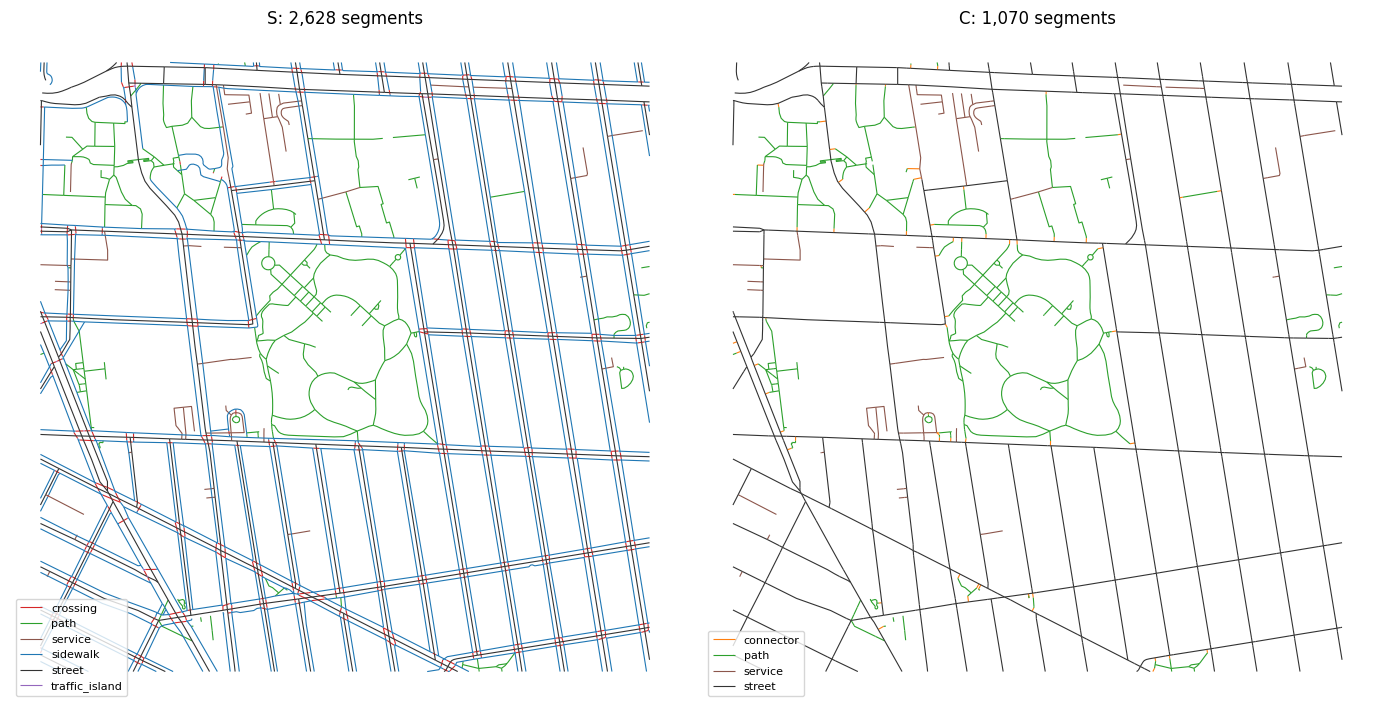

In [9]:
center = gpd.GeoSeries([Point(-73.9754, 40.6911)], crs=4326).to_crs(CRS).iloc[0]
win = center.buffer(600).envelope
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors = {"sidewalk": "#1f77b4", "crossing": "#d62728", "traffic_island": "#9467bd", "street": "#333333",
          "service": "#8c564b", "path": "#2ca02c", "connector": "#ff7f0e"}
for ax, (name, gdf) in zip(axes, [("S", S), ("C", C)]):
    sub = gdf[gdf.intersects(win)].clip(win)
    for k, g in sub.groupby("kind"):
        g.plot(ax=ax, color=colors.get(k, "grey"), linewidth=0.8, label=k)
    ax.set_title(f"{name}: {len(sub):,} segments")
    ax.legend(loc="lower left", fontsize=8)
    ax.set_axis_off()
plt.tight_layout()
plt.show()